# MÔ HÌNH HUẤN LUYỆN TITANIC

Trong phần này, em sẽ sử dụng lại các kết quả của file Feature, là công đoạn đã xử lý dữ liệu một cách kỹ càng, để xây dụng mô hình huận luyện. Trong notebook này sẽ sử dụng nhiều cách huấn luyện khác nhau như LogisticRegression, RandomForest, SVC (Support Vector Classifier), XGBOOOTS,.. để xem mô hình nào phù hợp nhất, dự đoán tốt nhất, từ đó xem xét đặc trưng nào là tốt nhất ảnh hưởng đến việc sống sót của các hành khách trên chuyến tàu titanic định mệnh.

**Các bước thực hiện**
1. Huấn luyện các mô hình Baseline.
2. Huấn luyện mô hình tinh chỉnh tham số.
3. Trực quan hóa các đặc trưng có ảnh hưởng đến việc sống sót của hành khách trên tàu.


### **Load các thư viện cần thiết và sử dụng lại kết quả từ file Feature**

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib # Để lưu mô hình
import warnings
# Tắt các cảnh báo không cần thiết
warnings.filterwarnings('ignore')

# Các thư viện sklearn
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb



Tất cả thư viện đã được import.


**Chạy file Feature để lấy phần dữ liệu đã được sử lý**

Kích thước dữ liệu huấn luyện: (891, 12)
Kích thước dữ liệu kiểm tra: (418, 11)
Kích thước dữ liệu tổng hợp: (1309, 11)
          Số lượng thiếu  Phần trăm (%)
Cabin               1014      77.463713
Age                  263      20.091673
Embarked               2       0.152788
Fare                   1       0.076394


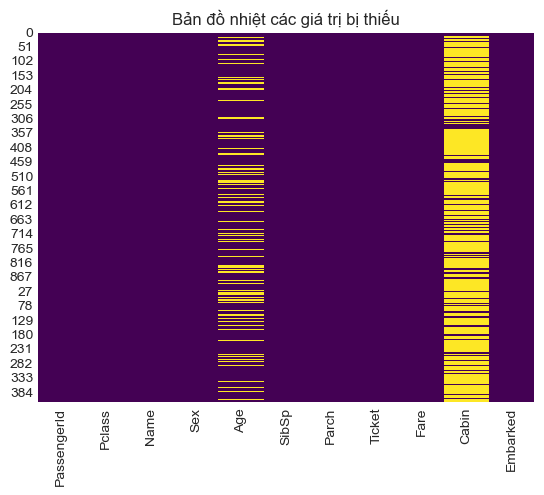

Giá trị điền cho 'Embarked' (mode): 'S'
Giá trị điền cho 'Fare' (median): 14.4542
Giá trị điền cho 'Age' (median): 28.0

Đã điền các giá trị thiếu cho Embarked, Fare, và Age.
Đã tạo cột 'HasCabin' và xóa cột 'Cabin'.

Số lượng giá trị thiếu còn lại:
PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64
Đã tạo các đặc trưng 'FamilySize' và 'IsAlone'.
Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Major         2
Mlle          2
Ms            2
Mme           1
Don           1
Sir           1
Lady          1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64

Danh xưng sau khi đã được nhóm lại:
Title
Mr        757
Miss      260
Mrs       197
Master     61
Rare       33
Don         1
Name: count, dtype: int64
Đã tạo các đặc trưng 'AgeBin'

,Pclass,Sex,HasCabin,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S,Title_Don,Title_Master,...,AgeBin_0,AgeBin_1,AgeBin_2,AgeBin_3,AgeBin_4,FareBin_0,FareBin_1,FareBin_2,FareBin_3,Survived
0,3,0,0,2,0,False,False,True,False,False,...,False,True,False,False,False,True,False,False,False,0
1,1,1,1,2,0,True,False,False,False,False,...,False,False,True,False,False,False,False,False,True,1
2,3,1,0,1,1,False,False,True,False,False,...,False,True,False,False,False,False,True,False,False,1
3,1,1,1,2,0,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,1
4,3,0,0,1,1,False,False,True,False,False,...,False,False,True,False,False,False,True,False,False,0



5 dòng đầu của tập test đã xử lý:


,Pclass,Sex,HasCabin,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S,Title_Don,Title_Master,...,Title_Rare,AgeBin_0,AgeBin_1,AgeBin_2,AgeBin_3,AgeBin_4,FareBin_0,FareBin_1,FareBin_2,FareBin_3
0,3,0,0,1,1,False,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False
1,3,1,0,2,0,False,False,True,False,False,...,False,False,False,True,False,False,True,False,False,False
2,2,0,0,1,1,False,True,False,False,False,...,False,False,False,False,True,False,False,True,False,False
3,3,0,0,1,1,False,False,True,False,False,...,False,False,True,False,False,False,False,True,False,False
4,3,1,0,3,0,False,False,True,False,False,...,False,False,True,False,False,False,False,True,False,False


In [27]:
%run ../Feature/Feature.ipynb

**Chia dữ liệu train và test**

In [ ]:
X_train = train_final.drop('Survived', axis=1)
y_train = train_final['Survived']


X_test = test_final

### Huấn luyện mô hình Baseline
Trong phần này, chúng ta đã huấn luyện và đánh giá hiệu suất ban đầu của một số mô hình học máy phổ biến trên tập dữ liệu huấn luyện đã được xử lý. Phương pháp đánh giá được sử dụng là **K-Fold Cross-Validation** (với K=5) để có được ước lượng hiệu suất đáng tin cậy hơn. Chỉ số đánh giá chính là **Độ chính xác (Accuracy)**.

* LogisticRegression: Mô hình tuyến tính, đơn giản, diễn giải được. Thường là điểm khởi đầu tốt cho bài toán phân loại nhị phân. Dựa trên hàm sigmoid để dự đoán xác suất.

* SVC: (Support Vector Classifier) Tìm mặt phẳng (hoặc siêu phẳng) tối ưu để phân tách các lớp dữ liệu. Mạnh mẽ với dữ liệu nhiều chiều và phi tuyến (khi dùng kernel phù hợp).

* Random Forest: Mô hình Ensemble (tập hợp) dựa trên nhiều cây quyết định. Giảm overfitting so với cây đơn lẻ bằng cách lấy trung bình dự đoán.

* Decision Tree: Mô hình dạng cây, dễ hiểu và diễn giải. Phân chia dữ liệu dựa trên các đặc trưng để đưa ra quyết định. Dễ bị overfitting nếu cây quá sâu.

* KNeighbors: (K-Nearest Neighbors) Phân loại một điểm dữ liệu dựa trên "ý kiến" của K hàng xóm gần nhất. Đơn giản, không cần giai đoạn huấn luyện phức tạp.

* XGBoost: (Extreme Gradient Boosting) Thuật toán boosting mạnh mẽ, thường cho hiệu suất cao. Xây dựng tuần tự các cây quyết định yếu để cải thiện lỗi.


In [30]:
print("Mô hình Baseline")

# Thiết lập số fold cho Cross-validation
k_fold = 5
kf = KFold(n_splits=k_fold, shuffle=True, random_state=42)

# 1. Định nghĩa các mô hình
models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'SVC': SVC(random_state=42),
    'KNeighbors': KNeighborsClassifier(),
    'XGBoost': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# 2. Huấn luyện và Đánh giá
results = []
for model_name, model in models.items():
    # Sử dụng cross_val_score để đánh giá
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
    
    results.append({
        'Model': model_name,
        'Mean Accuracy': scores.mean(),
        'Std Dev': scores.std()
    })
    print(f"Đã huấn luyện {model_name}. Accuracy: {scores.mean():.4f}")

# 3. Tạo DataFrame kết quả
results_df = pd.DataFrame(results).sort_values(by='Mean Accuracy', ascending=False)

print("\n--- Kết quả Đánh giá Baseline ---")
display(results_df)

Mô hình Baseline
Đã huấn luyện LogisticRegression. Accuracy: 0.8317
Đã huấn luyện DecisionTree. Accuracy: 0.8125
Đã huấn luyện RandomForest. Accuracy: 0.8125
Đã huấn luyện SVC. Accuracy: 0.8294
Đã huấn luyện KNeighbors. Accuracy: 0.8036
Đã huấn luyện XGBoost. Accuracy: 0.8148

--- Kết quả Đánh giá Baseline ---


,Model,Mean Accuracy,Std Dev
0,LogisticRegression,0.831655,0.025582
3,SVC,0.829408,0.019944
5,XGBoost,0.814795,0.026474
2,RandomForest,0.812548,0.021666
1,DecisionTree,0.812535,0.031270
4,KNeighbors,0.803590,0.023839


### Phân tích Chi tiết Lỗi Mô hình Baseline qua Ma trận Nhầm lẫn (Cross-Validation)

Để hiểu rõ hơn về cách từng mô hình baseline đưa ra dự đoán sai, chúng ta sử dụng **Ma trận Nhầm lẫn (Confusion Matrix)**. Ma trận này được tạo ra từ các dự đoán thu được thông qua quy trình **Cross-Validation** (`cross_val_predict`), đảm bảo rằng dự đoán cho mỗi hành khách được thực hiện bởi mô hình chưa "nhìn thấy" nhãn của hành khách đó trong quá trình huấn luyện fold tương ứng. Điều này mang lại đánh giá lỗi đáng tin cậy hơn so với việc chỉ chia dữ liệu một lần.

Ma trận nhầm lẫn cho mỗi mô hình được trình bày dưới dạng heatmap (sử dụng bảng màu 'viridis'):

* **Trục tung (Y-axis):** Nhãn thực tế (`True label`) - Hành khách thực sự Sống (1) hay Chết (0).
* **Trục hoành (X-axis):** Nhãn dự đoán (`Predicted label`) - Mô hình dự đoán hành khách Sống (1) hay Chết (0).



 Matrix Confusion (Cross-Validation) 

 Matrix Confusion for [LogisticRegression] 


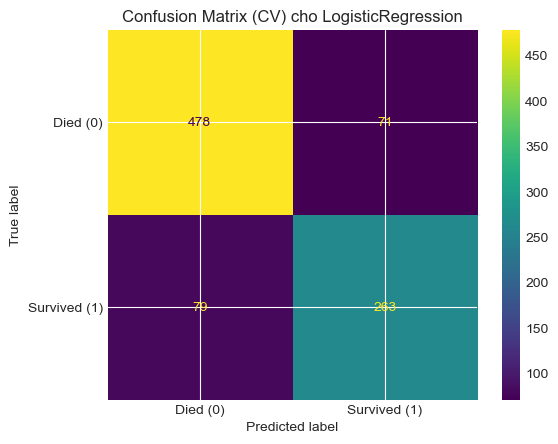


 Matrix Confusion for [DecisionTree] 


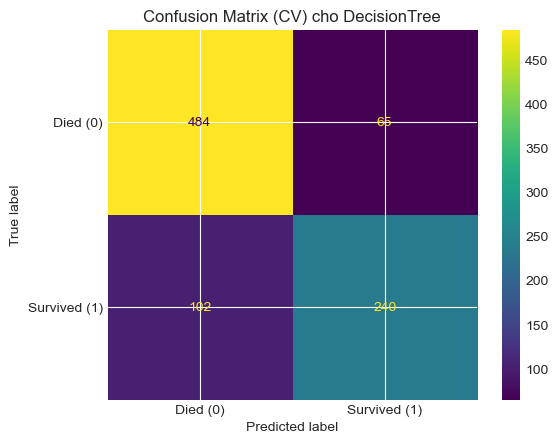


 Matrix Confusion for [RandomForest] 


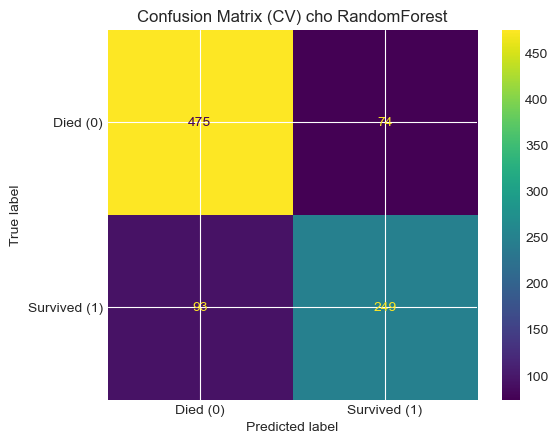


 Matrix Confusion for [SVC] 


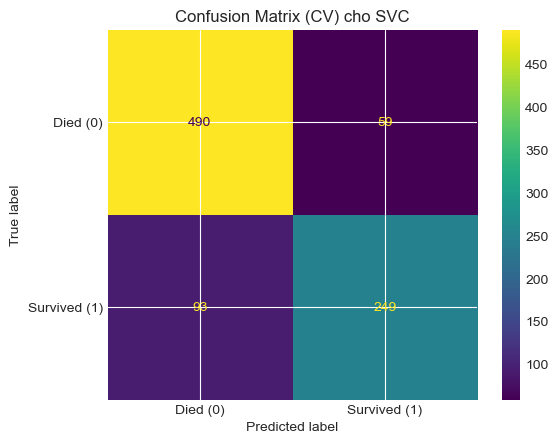


 Matrix Confusion for [KNeighbors] 


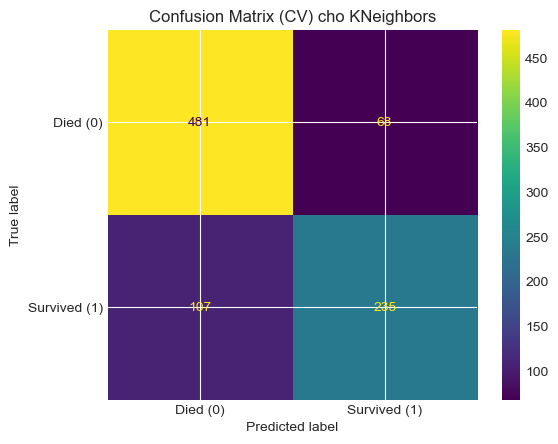


 Matrix Confusion for [XGBoost] 


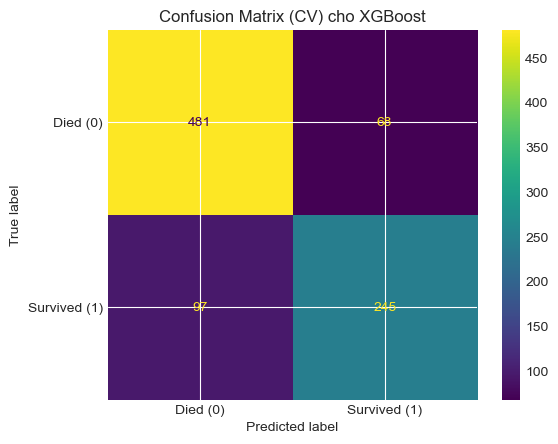

In [48]:

print("\n Matrix Confusion (Cross-Validation) ")

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
for model_name, model in models.items():
    print(f'\n Matrix Confusion for [{model_name}] ')

    # 1. Lấy dự đoán từ cross-validation
    #    Hàm này thực hiện K-Fold CV và trả về dự đoán cho từng điểm dữ liệu
    #    khi điểm đó nằm trong tập validation của một fold nào đó.
    y_pred_cv = cross_val_predict(model, X_train, y_train, cv=kf)

    # 2. Tính toán ma trận nhầm lẫn
    #    So sánh y_train (nhãn thực tế) với y_pred_cv (dự đoán từ CV)
    cm = confusion_matrix(y_train, y_pred_cv)

    # 3. Vẽ ma trận nhầm lẫn (Heatmap)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died (0)', 'Survived (1)'])
    disp.plot(cmap='viridis', values_format='d') # Thêm values_format='d' để chắc chắn hiển thị số nguyên
    plt.title(f'Confusion Matrix (CV) cho {model_name}')
    # Không cần plt.ylabel và plt.xlabel vì ConfusionMatrixDisplay tự xử lý
    plt.show()  


### Lưu kết quả của baseline 

In [31]:
print("\n Đang lưu kết quả thực nghiệm Baseline ")

# Định nghĩa tên file
excel_filename = 'baseline_model_results.xlsx'

# Sử dụng pd.ExcelWriter để lưu cả 2 DataFrame vào cùng 1 file, 2 sheet khác nhau
with pd.ExcelWriter(excel_filename) as writer:
    # Lưu kết quả K-Fold (Đáng tin cậy)
    results_df.to_excel(
        writer, 
        sheet_name='K-Fold_CV_Results', 
        index=False
    )
    
print(f"Đã lưu thành công 2 bảng kết quả vào file: '{excel_filename}'")


 Đang lưu kết quả thực nghiệm Baseline 
Đã lưu thành công 2 bảng kết quả vào file: 'baseline_model_results.xlsx'


### Trực quan hóa kết quả sau khi xây dựng mô hình baseline

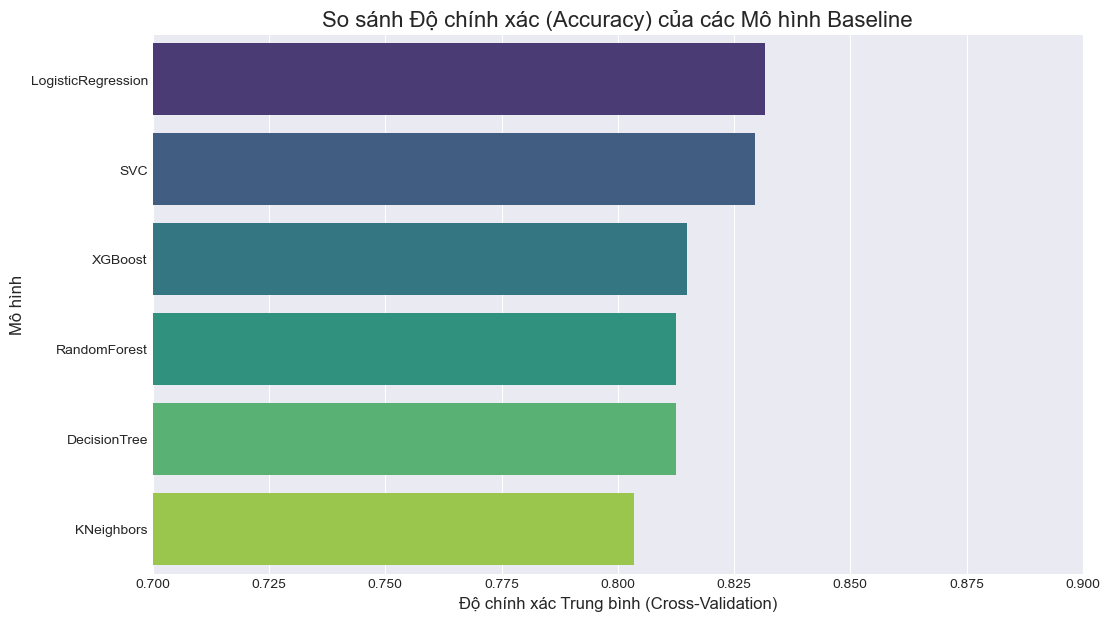

In [32]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Mean Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('So sánh Độ chính xác (Accuracy) của các Mô hình Baseline', fontsize=16)
plt.xlabel('Độ chính xác Trung bình (Cross-Validation)', fontsize=12)
plt.ylabel('Mô hình', fontsize=12)
plt.xlim(0.7, 0.9) # Đặt giới hạn trục x để thấy rõ
plt.show()

### Tinh chỉnh Tham số cho Mô hình Random Forest bằng GridSearchCV

Sau khi đánh giá các mô hình baseline, **Random Forest** được chọn để thực hiện tinh chỉnh tham số nhằm tìm ra cấu hình tối ưu, có khả năng cải thiện độ chính xác dự đoán. Phương pháp được sử dụng là **Grid Search Cross-Validation (`GridSearchCV`)**.

---

#### Quy trình Thực hiện

1.  **Định nghĩa Lưới Tham số (`param_grid_rf`):**
    Chúng ta xác định một tập hợp các giá trị khác nhau cho các tham số quan trọng của Random Forest để `GridSearchCV` thử nghiệm:
    * `n_estimators`: Số lượng cây quyết định trong rừng (100, 200, 300).
    * `max_depth`: Độ sâu tối đa của mỗi cây (Không giới hạn, 10, 20). Giúp kiểm soát độ phức tạp của cây.
    * `min_samples_leaf`: Số lượng mẫu tối thiểu cần có ở một nút lá (1, 2, 4). Giúp chống overfitting.
    * `min_samples_split`: Số lượng mẫu tối thiểu cần có để một nút có thể được chia (2, 5).
    * `max_features`: Số lượng đặc trưng tối đa được xem xét khi tìm cách chia tốt nhất ('sqrt': căn bậc hai của tổng số đặc trưng, 'log2': logarit cơ số 2).

2.  **Khởi tạo `GridSearchCV`:**
    Đối tượng `GridSearchCV` được tạo với:
    * `estimator`: Mô hình `RandomForestClassifier` ban đầu (với `random_state=42`).
    * `param_grid`: Lưới tham số đã định nghĩa ở trên.
    * `cv`: Đối tượng K-Fold Cross-Validation (`kf`, k=5) đã tạo trước đó để đánh giá từng tổ hợp tham số.
    * `scoring`: Chỉ số đánh giá là 'accuracy'.
    * `n_jobs=-1`: Sử dụng tất cả các nhân CPU có sẵn để tăng tốc quá trình tìm kiếm.
    * `verbose=1`: Hiển thị thông tin trong quá trình huấn luyện.

3.  **Huấn luyện:**
    Phương thức `.fit(X_train, y_train)` được gọi để bắt đầu quá trình tìm kiếm. `GridSearchCV` sẽ huấn luyện và đánh giá (bằng CV) mô hình Random Forest với mọi tổ hợp tham số có thể có trong `param_grid_rf`.

---

#### Kết quả Tinh chỉnh

Sau khi quá trình tìm kiếm hoàn tất, `GridSearchCV` đã xác định được bộ tham số cho kết quả tốt nhất:

* **Độ chính xác (Accuracy) tốt nhất (trung bình qua 5-Fold CV):** `0.8350` (hoặc giá trị `best_accuracy` thu được khi chạy code)
* **Bộ tham số (Hyperparameters) tốt nhất:** `{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}` (hoặc giá trị `best_params` thu được khi chạy code)

---

#### Kết luận

Việc sử dụng `GridSearchCV` đã giúp chúng ta tìm ra một cấu hình Random Forest tốt hơn so với cấu hình mặc định ban đầu, cải thiện độ chính xác trung bình trên cross-validation từ `0.8125` lên khoảng `0.8350`. Mô hình với bộ tham số tốt nhất này (`best_model`) sẽ được sử dụng để trực quan hóa độ quan trọng của đặc trưng và tạo file dự đoán cuối cùng. ✨

In [ ]:
print("\n Cải thiện Mô hình (GridSearchCV) ")
print("Chọn Random Forest để tinh chỉnh ")

# 1. Định nghĩa lưới tham số (param_grid)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

# 2. Khởi tạo GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=kf, # Sử dụng k-fold đã định nghĩa
    scoring='accuracy',
    n_jobs=-1, # Dùng tất cả CPU
    verbose=1
)

# 3. Huấn luyện (sẽ mất một lúc)
grid_search.fit(X_train, y_train)

# 4. Lấy ra mô hình và kết quả tốt nhất
best_model = grid_search.best_estimator_
best_accuracy = grid_search.best_score_
best_params = grid_search.best_params_

print("\n Hoàn tất! ")
print(f"Độ chính xác tốt nhất: {best_accuracy:.4f}")
print(f"Bộ tham số tốt nhất: {best_params}")


 Cải thiện Mô hình (GridSearchCV) 
Chọn Random Forest để tinh chỉnh 
Fitting 5 folds for each of 108 candidates, totalling 540 fits

--- Hoàn tất tinh chỉnh! ---
Độ chính xác tốt nhất: 0.8350
Bộ tham số tốt nhất: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}


---

### Phân tích Độ Quan trọng của Đặc trưng (Random Forest đã Tinh chỉnh)

Để hiểu rõ hơn những yếu tố nào ảnh hưởng nhiều nhất đến quyết định sống/chết của mô hình Random Forest đã được tối ưu hóa, chúng ta tiến hành phân tích **Độ quan trọng của Đặc trưng (Feature Importance)**.

---

#### Phương pháp

1.  **Trích xuất Độ quan trọng:** Chúng ta lấy thuộc tính `feature_importances_` từ mô hình Random Forest tốt nhất (`best_model`) thu được sau quá trình `GridSearchCV`. Thuộc tính này cho biết mức độ đóng góp trung bình của mỗi đặc trưng vào việc giảm độ tinh khiết (impurity reduction) hoặc cải thiện độ chính xác qua tất cả các cây trong rừng.
2.  **Tạo DataFrame:** Một DataFrame (`importance_df`) được tạo ra để ghép tên của từng đặc trưng (`feature_names`) với điểm số quan trọng tương ứng.
3.  **Sắp xếp:** DataFrame được sắp xếp theo thứ tự giảm dần của điểm số quan trọng.
4.  **Trực quan hóa:** Sử dụng biểu đồ cột ngang (`seaborn.barplot`) để hiển thị **15 đặc trưng quan trọng nhất** cùng với điểm số của chúng. Bảng màu 'plasma' được sử dụng để trực quan hóa.

*(Biểu đồ cột hiển thị 15 đặc trưng quan trọng nhất sẽ được hiển thị ở đây sau khi chạy code)*

---

#### Quan sát và Diễn giải (Dựa trên biểu đồ):


* **`Title_Mr` (Danh xưng "Mr.")** là đặc trưng có ảnh hưởng lớn nhất đến dự đoán của mô hình. Điều này phù hợp với phân tích dữ liệu ban đầu, cho thấy nam giới có tỷ lệ sống sót thấp hơn đáng kể.
* **`Sex` (Giới tính)** là đặc trưng quan trọng thứ hai, khẳng định vai trò then chốt của giới tính trong việc xác định khả năng sống sót (ưu tiên "phụ nữ và trẻ em").
* **`Pclass` (Hạng vé)** đứng thứ ba, cho thấy điều kiện kinh tế xã hội (phản ánh qua hạng vé) cũng là một yếu tố dự đoán mạnh mẽ.
* Các đặc trưng khác trong top đầu bao gồm **`Title_Miss`**, **`FamilySize`** (Kích thước gia đình), **`HasCabin`** (Có thông tin cabin hay không), **`Title_Mrs`**, và các khoảng giá vé/tuổi (`FareBin_*`, `AgeBin_*`) cho thấy các đặc trưng được tạo ra (engineered features) cũng đóng góp đáng kể vào mô hình.
* Sự xuất hiện của các đặc trưng như **`Embarked_S`** (Cảng lên tàu Southampton) và **`IsAlone`** (Đi một mình) trong top 15 cũng cho thấy sự ảnh hưởng, dù nhỏ hơn, của các yếu tố này.

---

#### Kết luận

Phân tích độ quan trọng của đặc trưng từ mô hình Random Forest đã tinh chỉnh xác nhận rằng các yếu tố như **danh xưng (liên quan đến giới tính, tuổi, tình trạng hôn nhân), giới tính, và hạng vé** là những yếu tố dự báo mạnh nhất cho khả năng sống sót trên tàu Titanic. Các đặc trưng được tạo ra trong quá trình tiền xử lý cũng mang lại giá trị thông tin hữu ích cho mô hình. Việc hiểu rõ các đặc trưng quan trọng giúp chúng ta tin tưởng hơn vào mô hình và giải thích được cách nó đưa ra dự đoán. 


Trực quan hóa Mô hình


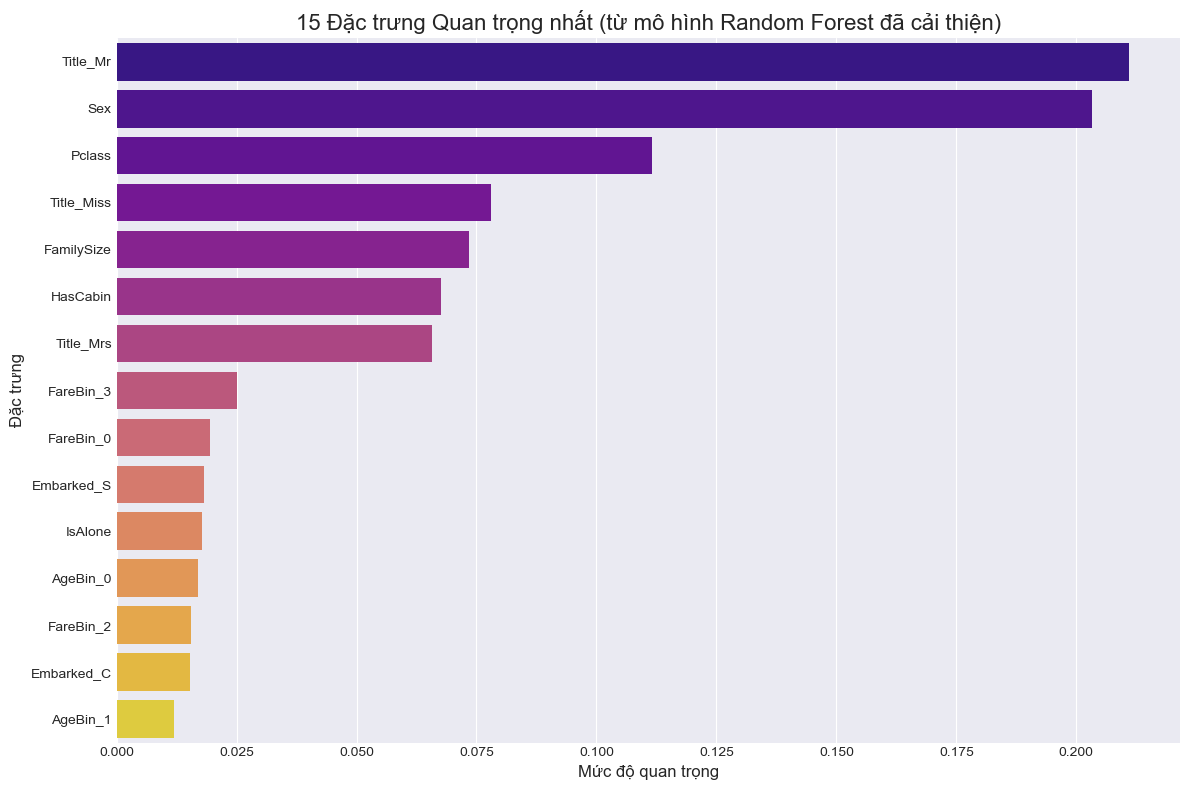

In [34]:
print("\nTrực quan hóa Mô hình")

# Lấy Mức độ quan trọng của Đặc trưng
importances = best_model.feature_importances_
feature_names = X_train.columns

# Tạo DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='plasma')
plt.title(f'15 Đặc trưng Quan trọng nhất (từ mô hình Random Forest đã cải thiện)', fontsize=16)
plt.xlabel('Mức độ quan trọng', fontsize=12)
plt.ylabel('Đặc trưng', fontsize=12)
plt.tight_layout()
plt.show()

### Lưu kết quả từ mô hình cải thiện của RandomForest 

In [ ]:
print("\n Lưu Mô hình & Xuất file Nộp bài ")


model_filename = f'titanic_best_{best_model.__class__.__name__}.joblib'
joblib.dump(best_model, model_filename)
print(f"Đã lưu mô hình tốt nhất vào file: {model_filename}")

# 2. Dự đoán trên tập Test
predictions = best_model.predict(X_test)

# 3. Tạo file submission
submission_df = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': predictions
})

# 4. Lưu file submission
submission_filename = f'submission_{best_model.__class__.__name__}_tuned.csv'
submission_df.to_csv(submission_filename, index=False)
print(f"Đã lưu file nộp bài vào file: {submission_filename}")

# Hiển thị 5 dòng đầu của file nộp bài
display(submission_df.head())


--- Lưu Mô hình & Xuất file Nộp bài ---
Đã lưu mô hình tốt nhất vào file: titanic_best_RandomForestClassifier.joblib
Đã lưu file nộp bài vào file: submission_RandomForestClassifier_tuned.csv


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


### Tinh chỉnh Tham số cho Mô hình Logistic Regression bằng GridSearchCV

Dựa trên kết quả đánh giá baseline, **Logistic Regression** là một trong những mô hình cho độ chính xác cao nhất. Do đó, chúng ta tiến hành tinh chỉnh tham số cho mô hình này bằng **Grid Search Cross-Validation (`GridSearchCV`)** để tìm ra cấu hình tốt nhất có thể.

---

#### Quy trình Thực hiện

1.  **Định nghĩa Lưới Tham số (`param_grid_lr`):**
    Một lưới các giá trị tham số được xác định để `GridSearchCV` thử nghiệm:
    * `C`: Nghịch đảo của cường độ điều chuẩn (Regularization strength). Các giá trị [0.01, 0.1, 1, 10, 100] được thử nghiệm, từ điều chuẩn mạnh đến yếu.
    * `solver`: Thuật toán tối ưu hóa được sử dụng. ['liblinear', 'lbfgs'] là hai lựa chọn phổ biến được thử.
    * `max_iter`: Số lần lặp tối đa cho thuật toán tối ưu hóa [1000, 2000], được tăng lên để đảm bảo sự hội tụ.

2.  **Khởi tạo `GridSearchCV`:**
    Đối tượng `GridSearchCV` được cấu hình với:
    * `estimator`: Mô hình `LogisticRegression` ban đầu (với `random_state=42`).
    * `param_grid`: Lưới tham số `param_grid_lr`.
    * `cv`: Đối tượng K-Fold Cross-Validation (`kf`, k=5).
    * `scoring`: Chỉ số 'accuracy'.
    * `n_jobs=-1`: Sử dụng tất cả CPU.
    * `verbose=1`: Hiển thị tiến trình.

3.  **Huấn luyện:**
    Phương thức `.fit(X_train, y_train)` được thực thi. Quá trình này nhanh hơn đáng kể so với Random Forest do Logistic Regression là mô hình đơn giản hơn.

---

#### Kết quả Tinh chỉnh

Sau khi hoàn tất, `GridSearchCV` cho kết quả như sau:

* **Độ chính xác (Accuracy) tốt nhất (trung bình qua 5-Fold CV):** `0.8317` (hoặc giá trị `best_accuracy` thu được)
* **Bộ tham số (Hyperparameters) tốt nhất:** `{'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}` (hoặc giá trị `best_params` thu được)

---

#### Kết luận

Quá trình tinh chỉnh tham số cho Logistic Regression cho thấy rằng cấu hình với `C=1` (mức điều chuẩn trung bình), `solver='lbfgs'`, và `max_iter=1000` mang lại độ chính xác tốt nhất trên cross-validation. Độ chính xác này (`0.8317`) gần như không thay đổi so với mô hình baseline (`0.8317`), điều này cho thấy các tham số mặc định của Logistic Regression đã khá tốt cho tập dữ liệu này, hoặc lưới tham số chưa đủ rộng để tìm ra sự cải thiện đáng kể. Mô hình tốt nhất này (`best_model`) sẽ được sử dụng cho các bước tiếp theo. 

In [ ]:
print("\n Cải thiện Mô hình (GridSearchCV) ")
print("Chọn Logistic Regression để tinh chỉnh...")

# 1. Định nghĩa lưới tham số (param_grid) cho LogisticRegression
#
# Giải thích các tham số:
# 'C': Đây là tham số quan trọng nhất (nghịch đảo của cường độ điều chuẩn). 
#      Giá trị 'C' nhỏ nghĩa là điều chuẩn MẠNH hơn (tránh overfitting).
#      Giá trị 'C' lớn nghĩa là điều chuẩn YẾU hơn (cố gắng khớp dữ liệu huấn luyện).
# 'solver': Các thuật toán tối ưu hóa khác nhau. 
#           'liblinear' tốt cho tập dữ liệu nhỏ. 
#           'lbfgs' và 'saga' là các lựa chọn phổ biến khác.
# 'max_iter': Tăng số lần lặp để đảm bảo các solver hội tụ (tìm được kết quả).

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],  # Thử các mức độ điều chuẩn khác nhau
    'solver': ['liblinear', 'lbfgs'], # Thử các thuật toán tối ưu
    'max_iter': [1000, 2000]         # Tăng max_iter để tránh lỗi không hội tụ
}

# 2. Khởi tạo GridSearchCV
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42), # Mô hình gốc
    param_grid=param_grid_lr,                      # Lưới tham số
    cv=kf,                                         # Sử dụng k-fold đã định nghĩa
    scoring='accuracy',                            # Thước đo
    n_jobs=-1,                                     # Dùng tất cả CPU
    verbose=1                                      # Hiển thị tiến trình
)

# 3. Huấn luyện (sẽ nhanh hơn RandomForest rất nhiều)
grid_search.fit(X_train, y_train)

# 4. Lấy ra mô hình và kết quả tốt nhất
best_model = grid_search.best_estimator_ # Đây là mô hình tốt nhất
best_accuracy = grid_search.best_score_
best_params = grid_search.best_params_

print("\n Hoàn tất tinh chỉnh (LogisticRegression)! ")
print(f"Độ chính xác tốt nhất: {best_accuracy:.4f}")
print(f"Bộ tham số tốt nhất: {best_params}")


--- Cải thiện Mô hình (GridSearchCV) ---
Chọn Logistic Regression để tinh chỉnh...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

--- Hoàn tất tinh chỉnh (LogisticRegression)! ---
Độ chính xác tốt nhất: 0.8317
Bộ tham số tốt nhất: {'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}


### Phân tích Ảnh hưởng của Đặc trưng (Logistic Regression đã Tinh chỉnh)

Để hiểu các đặc trưng ảnh hưởng như thế nào đến dự đoán của mô hình **Logistic Regression** tốt nhất (đã được tinh chỉnh bằng `GridSearchCV`), chúng ta phân tích các **hệ số (coefficients)** mà mô hình đã học được.

---

#### Phương pháp

Khác với Random Forest, Logistic Regression không có thuộc tính `feature_importances_`. Thay vào đó, chúng ta sử dụng thuộc tính `coef_`, chứa các hệ số tương ứng với từng đặc trưng.

1.  **Trích xuất Hệ số:** Lấy mảng `coef_[0]` từ mô hình Logistic Regression tốt nhất (`best_model`). Chỉ số `[0]` được sử dụng vì đây là bài toán phân loại nhị phân, chỉ có một tập hệ số.
2.  **Tạo DataFrame:** Một DataFrame (`importance_df`) được tạo để liên kết tên đặc trưng (`feature_names`) với hệ số (`Coefficient`) tương ứng.
3.  **Sắp xếp:** Để xác định các đặc trưng có ảnh hưởng **mạnh nhất** (cả tích cực và tiêu cực) đến dự đoán, DataFrame được sắp xếp theo **giá trị tuyệt đối** của hệ số (`Absolute Coefficient`) theo thứ tự giảm dần.
4.  **Trực quan hóa:**
    * Sử dụng biểu đồ cột ngang (`seaborn.barplot`) để hiển thị **15 đặc trưng có giá trị tuyệt đối của hệ số lớn nhất**.
    * Trục X biểu thị giá trị của hệ số (`Coefficient`).
    * Trục Y liệt kê tên các đặc trưng (`Feature`).
    * Bảng màu `coolwarm` được sử dụng: màu **ấm (đỏ)** thường biểu thị hệ số **dương**, màu **lạnh (xanh)** biểu thị hệ số **âm**.
    * Một đường kẻ dọc (`axvline`) tại x=0 được thêm vào để dễ dàng phân biệt hệ số dương và âm.

*(Biểu đồ cột hiển thị 15 đặc trưng ảnh hưởng nhất sẽ được hiển thị ở đây sau khi chạy code)*

---

#### Diễn giải Kết quả (Dựa trên biểu đồ):



* **Hệ số Dương (Màu ấm/đỏ):** Đặc trưng có hệ số dương lớn cho thấy rằng khi giá trị của đặc trưng đó tăng (hoặc khi đặc trưng đó có mặt, đối với biến nhị phân), xác suất **sống sót** (nhãn 1) **tăng lên**. Ví dụ, `Sex` (nếu mã hóa nữ = 1) hoặc `Title_Mrs`/`Title_Miss` thường có hệ số dương mạnh.
* **Hệ số Âm (Màu lạnh/xanh):** Đặc trưng có hệ số âm lớn (giá trị tuyệt đối lớn) cho thấy rằng khi giá trị của đặc trưng đó tăng, xác suất **sống sót** (nhãn 1) **giảm đi** (tức là tăng xác suất chết - nhãn 0). Ví dụ, `Title_Mr` hoặc `Pclass` (hạng 3) thường có hệ số âm mạnh.
* **Độ lớn của Hệ số:** Giá trị tuyệt đối của hệ số càng lớn, đặc trưng đó càng có ảnh hưởng mạnh mẽ đến kết quả dự đoán của mô hình Logistic Regression. Các đặc trưng có hệ số gần 0 có ít ảnh hưởng hơn.

---

#### Kết luận

Phân tích hệ số của mô hình Logistic Regression cung cấp một cách diễn giải trực quan về mối quan hệ tuyến tính mà mô hình đã học được giữa các đặc trưng và khả năng sống sót. Các đặc trưng như **danh xưng, giới tính, hạng vé** tiếp tục cho thấy ảnh hưởng đáng kể, phù hợp với kết quả từ Random Forest và hiểu biết chung về thảm họa Titanic. Việc này giúp xác nhận lại tầm quan trọng của các yếu tố này trong bài toán dự đoán. 


 Trực quan hóa Mô hình Tốt nhất (LogisticRegression)


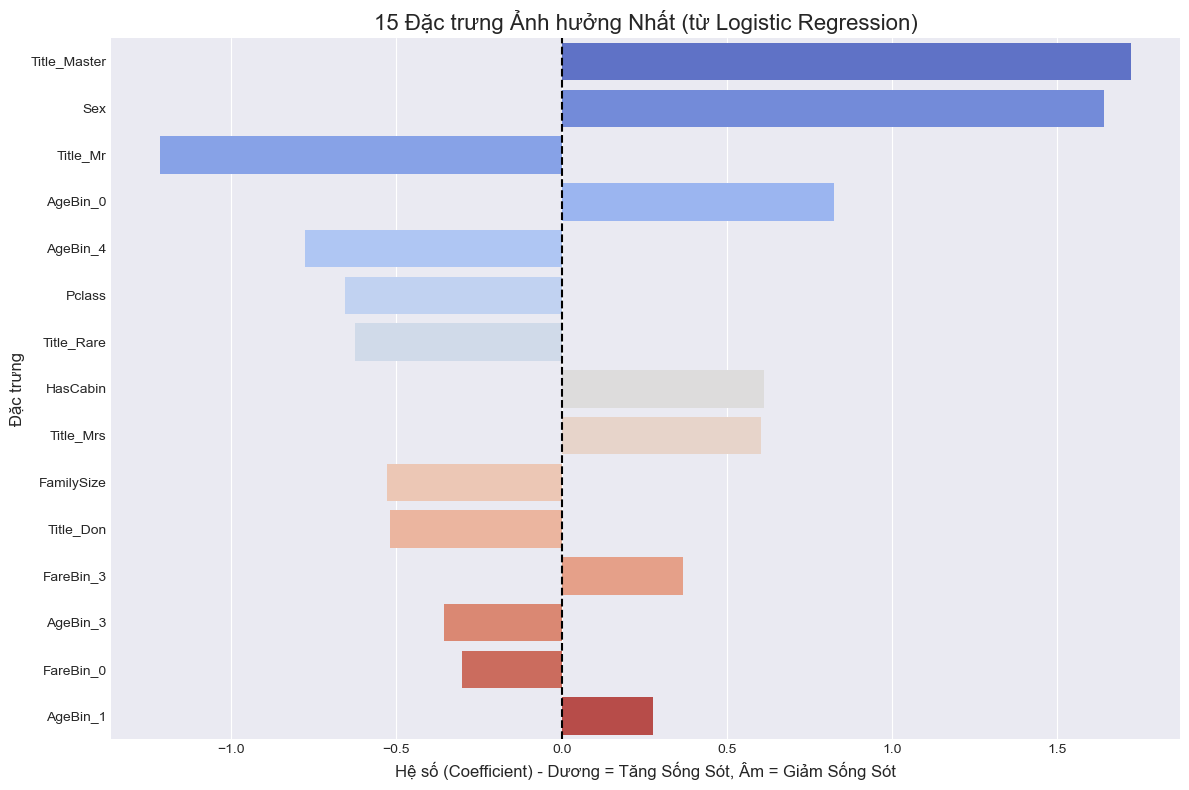

In [37]:
print("\n Trực quan hóa Mô hình Tốt nhất (LogisticRegression)")

# LogisticRegression không có 'feature_importances_'
# Thay vào đó, chúng ta dùng 'coef_' (hệ số)

# 1. Lấy các hệ số từ mô hình tốt nhất
# best_model của bạn bây giờ là LogisticRegression
# .coef_[0] vì đây là mô hình nhị phân (chỉ có 1 hàng hệ số)
coefficients = best_model.coef_[0] 
feature_names = X_train.columns

# 2. Tạo DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# 3. Sắp xếp dựa trên GIÁ TRỊ TUYỆT ĐỐI của hệ số
# để xem các đặc trưng ảnh hưởng MẠNH NHẤT (cả âm và dương)
importance_df['Absolute Coefficient'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Absolute Coefficient', ascending=False)

# 4. Vẽ biểu đồ
plt.figure(figsize=(12, 8))
# Sử dụng palette 'coolwarm' (hoặc 'Spectral') để màu đỏ là dương, xanh là âm
sns.barplot(
    x='Coefficient', 
    y='Feature', 
    data=importance_df.head(15), 
    palette='coolwarm'
)

# Thêm một đường dọc ở số 0 để dễ dàng phân biệt âm/dương
plt.axvline(x=0, color='black', linestyle='--') 

plt.title(f'15 Đặc trưng Ảnh hưởng Nhất (từ Logistic Regression)', fontsize=16)
plt.xlabel('Hệ số (Coefficient) - Dương = Tăng Sống Sót, Âm = Giảm Sống Sót', fontsize=12)
plt.ylabel('Đặc trưng', fontsize=12)
plt.tight_layout()
plt.show()

### Lưu kết quả của mô hình cải thiện LogisticRegression

In [38]:
print("\n--- Lưu Mô hình & Xuất file Nộp bài ---")


model_filename = f'titanic_best_{best_model.__class__.__name__}.joblib'
joblib.dump(best_model, model_filename)
print(f"Đã lưu mô hình tốt nhất vào file: {model_filename}")

# 2. Dự đoán trên tập Test
predictions = best_model.predict(X_test)

# 3. Tạo file submission
submission_df = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': predictions
})

# 4. Lưu file submission
submission_filename = f'submission_{best_model.__class__.__name__}_tuned.csv'
submission_df.to_csv(submission_filename, index=False)
print(f"Đã lưu file nộp bài vào file: {submission_filename}")

# Hiển thị 5 dòng đầu của file nộp bài
display(submission_df.head())


--- Lưu Mô hình & Xuất file Nộp bài ---
Đã lưu mô hình tốt nhất vào file: titanic_best_LogisticRegression.joblib
Đã lưu file nộp bài vào file: submission_LogisticRegression_tuned.csv


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


### Tinh chỉnh Tham số cho Mô hình SVC bằng GridSearchCV

Mô hình **Support Vector Classifier (SVC)** cũng cho thấy hiệu suất baseline khá tốt, nên nó được chọn để tinh chỉnh tham số bằng **Grid Search Cross-Validation (`GridSearchCV`)**. Mục tiêu là tìm ra tổ hợp `C`, `kernel`, và `gamma` tối ưu để cải thiện độ chính xác.

---

#### Quy trình Thực hiện

1.  **Định nghĩa Lưới Tham số (`param_grid_svc`):**
    Chúng ta thiết lập các giá trị cần thử nghiệm cho các tham số chính của SVC:
    * `C`: Tham số điều chuẩn (Regularization parameter). Các giá trị [0.1, 1, 10, 100] được kiểm tra, ảnh hưởng đến mức độ chấp nhận lỗi (margin violation).
    * `kernel`: Loại kernel sử dụng để biến đổi dữ liệu. ['linear', 'rbf'] là hai loại phổ biến nhất được thử. 'linear' cho mô hình tuyến tính, 'rbf' (Radial Basis Function) cho mô hình phi tuyến.
    * `gamma`: Tham số của kernel 'rbf'. ['scale', 'auto'] là các giá trị mặc định thường dùng, ảnh hưởng đến độ "lan tỏa" của ảnh hưởng từ một điểm dữ liệu.

2.  **Khởi tạo `GridSearchCV`:**
    Đối tượng `GridSearchCV` được tạo với:
    * `estimator`: Mô hình `SVC` ban đầu (với `probability=True` để có thể lấy xác suất dự đoán nếu cần sau này, và `random_state=42`).
    * `param_grid`: Lưới tham số `param_grid_svc`.
    * `cv`: Đối tượng K-Fold Cross-Validation (`kf`, k=5).
    * `scoring`: Chỉ số 'accuracy'.
    * `n_jobs=-1`: Sử dụng tất cả CPU.
    * `verbose=1`: Hiển thị tiến trình.

3.  **Huấn luyện:**
    Thực hiện `.fit(X_train, y_train)`. Quá trình này có thể tốn thời gian hơn Logistic Regression do tính toán phức tạp hơn, đặc biệt với kernel 'rbf'.

---

#### Kết quả Tinh chỉnh

Sau khi chạy `GridSearchCV`, kết quả tốt nhất thu được là:

* **Độ chính xác (Accuracy) tốt nhất (trung bình qua 5-Fold CV):** `0.8316` (hoặc giá trị `best_accuracy` thu được)
* **Bộ tham số (Hyperparameters) tốt nhất:** `{'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}` (hoặc giá trị `best_params` thu được)

---

#### Kết luận

Quá trình tinh chỉnh cho thấy mô hình SVC với kernel `rbf`, `C=1`, và `gamma='auto'` cho độ chính xác tốt nhất trên cross-validation là `0.8316`. Kết quả này cao hơn một chút so với mô hình SVC baseline (`0.8294`). Điều này cho thấy kernel phi tuyến `rbf` với các tham số này phù hợp hơn kernel `linear` (mặc định) cho tập dữ liệu này, mặc dù sự cải thiện không quá lớn so với Logistic Regression đã tinh chỉnh. Mô hình SVC tốt nhất (`best_model`) này cũng là một ứng viên tốt để tạo file submission. 

In [39]:
print("\n Cải thiện Mô hình (GridSearchCV) ")
print("Chọn SVC (Support Vector Classifier) để tinh chỉnh...")

# 1. Định nghĩa lưới tham số (param_grid) cho SVC
#
# Giải thích các tham số:
# 'C': Tham số điều chuẩn. Giá trị 'C' lớn có thể dẫn đến overfitting.
# 'kernel': 
#     - 'linear': Mô hình tuyến tính (giống LogisticRegression).
#     - 'rbf' (Radial Basis Function): Mô hình phi tuyến, rất mạnh mẽ.
# 'gamma': Tham số của kernel 'rbf'. 
#          'scale' và 'auto' là các giá trị mặc định tốt.

param_grid_svc = {
    'C': [0.1, 1, 10, 100],            # Thử các mức độ điều chuẩn
    'kernel': ['linear', 'rbf'],       # Thử 2 kernel phổ biến nhất
    'gamma': ['scale', 'auto']         # Thử các giá trị gamma cho 'rbf'
}

# 2. Khởi tạo GridSearchCV
grid_search = GridSearchCV(
    estimator=SVC(probability=True, random_state=42), # probability=True nếu bạn muốn dùng Soft Voting sau này
    param_grid=param_grid_svc,
    cv=kf,                                           # Sử dụng k-fold đã định nghĩa
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 3. Huấn luyện (Có thể sẽ mất một lúc, lâu hơn LogisticRegression)
grid_search.fit(X_train, y_train)

# 4. Lấy ra mô hình và kết quả tốt nhất
best_model = grid_search.best_estimator_ # Đây là mô hình tốt nhất
best_accuracy = grid_search.best_score_
best_params = grid_search.best_params_

print("\n--- Hoàn tất tinh chỉnh (SVC)! ---")
print(f"Độ chính xác tốt nhất: {best_accuracy:.4f}")
print(f"Bộ tham số tốt nhất: {best_params}")


 Cải thiện Mô hình (GridSearchCV) 
Chọn SVC (Support Vector Classifier) để tinh chỉnh...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

--- Hoàn tất tinh chỉnh (SVC)! ---
Độ chính xác tốt nhất: 0.8316
Bộ tham số tốt nhất: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}


### Trực quan hóa Mô hình SVC Tốt nhất

Sau khi tìm được mô hình SVC tốt nhất thông qua `GridSearchCV`, bước tiếp theo là trực quan hóa để hiểu rõ hơn về cách mô hình hoạt động hoặc đánh giá chi tiết lỗi của nó. Phương pháp trực quan hóa phụ thuộc vào loại `kernel` mà `GridSearchCV` đã chọn là tốt nhất.

---

#### Phương pháp Thực hiện

1.  **Kiểm tra Kernel:** Code kiểm tra giá trị của `best_model.kernel`.
    * **Nếu `kernel` là 'linear':** Mô hình SVC tuyến tính có thuộc tính `coef_` (tương tự Logistic Regression), thể hiện hệ số ảnh hưởng của từng đặc trưng.
        * Trích xuất hệ số `coef_[0]`.
        * Tạo DataFrame, sắp xếp theo giá trị tuyệt đối của hệ số.
        * Vẽ biểu đồ cột ngang (`barplot`) hiển thị 15 đặc trưng có hệ số tuyệt đối lớn nhất, sử dụng màu `coolwarm` để phân biệt ảnh hưởng dương/âm đến khả năng sống sót.
    * **Nếu `kernel` là 'rbf' (hoặc 'poly', 'sigmoid'):** Các kernel phi tuyến này không có thuộc tính `coef_` hay `feature_importances_` dễ diễn giải trực tiếp.
        * Thay vào đó, code sử dụng `cross_val_predict` để lấy dự đoán trên toàn bộ tập huấn luyện thông qua cross-validation.
        * Tính toán **Ma trận Nhầm lẫn (Confusion Matrix)** bằng cách so sánh dự đoán (`y_pred_cv`) với nhãn thực tế (`y_train`).
        * Vẽ ma trận nhầm lẫn dưới dạng heatmap (`sns.heatmap`) sử dụng màu `Blues`, hiển thị rõ số lượng dự đoán Đúng Âm (TN), Dương Tính Giả (FP), Âm Tính Giả (FN), và Đúng Dương (TP).

---

#### Kết quả Trực quan hóa

*(Tùy thuộc vào kết quả `best_kernel` từ `GridSearchCV`, một trong hai loại biểu đồ sau sẽ được hiển thị):*

* **Biểu đồ Hệ số (nếu kernel='linear'):**  Cho thấy đặc trưng nào (ví dụ: `Title_Mr`, `Sex`, `Pclass`) có ảnh hưởng tuyến tính mạnh nhất (dương hoặc âm) đến dự đoán sống sót.
* **Ma trận Nhầm lẫn (nếu kernel='rbf', etc.):**  Cung cấp cái nhìn chi tiết về các loại lỗi mà mô hình mắc phải (dự đoán sai người chết thành sống - FP, và dự đoán sai người sống thành chết - FN) dựa trên kết quả cross-validation.

---

#### Ý nghĩa

Việc trực quan hóa này giúp:

* **Hiểu mô hình (nếu kernel='linear'):** Xác định các đặc trưng quan trọng nhất theo góc nhìn tuyến tính.
* **Đánh giá lỗi (nếu kernel='rbf', etc.):** Phân tích cụ thể các loại sai sót mà mô hình phi tuyến mắc phải, từ đó có thể đưa ra các chiến lược cải thiện tiếp theo (ví dụ: xử lý mất cân bằng lớp nếu FN hoặc FP quá cao). 


--- Trực quan hóa Mô hình Tốt nhất (SVC) ---
Mô hình SVC tốt nhất dùng kernel 'rbf'.
Kernel này không có thuộc tính .coef_ hoặc .feature_importances_.
-> Thay vào đó, chúng ta sẽ trực quan hóa MA TRẬN NHẦM LẪN (Confusion Matrix)...


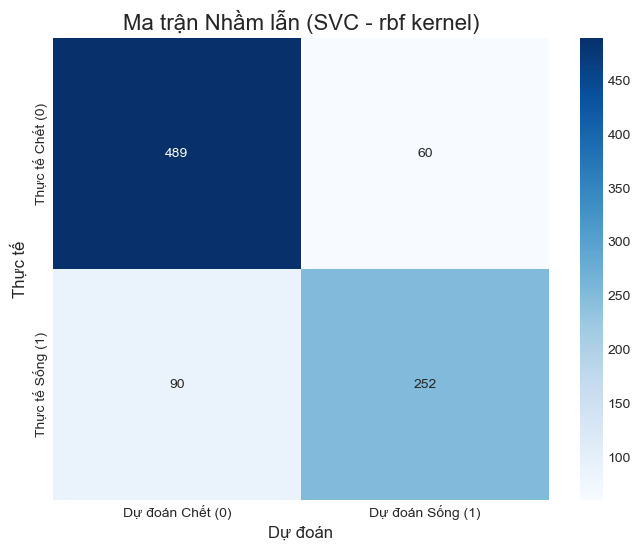

In [40]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

print("\n--- Trực quan hóa Mô hình Tốt nhất (SVC) ---")

# Lấy kernel tốt nhất mà GridSearchCV đã chọn
best_kernel = best_model.kernel

if best_kernel == 'linear':
    print("Mô hình SVC tốt nhất dùng kernel 'linear'. Trực quan hóa hệ số (coef_)...")
    
    # 1. Lấy hệ số (giống LogisticRegression)
    coefficients = best_model.coef_[0]
    feature_names = X_train.columns

    # 2. Tạo DataFrame
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients
    })
    importance_df['Absolute Coefficient'] = importance_df['Coefficient'].abs()
    importance_df = importance_df.sort_values(by='Absolute Coefficient', ascending=False)

    # 3. Vẽ biểu đồ hệ số
    plt.figure(figsize=(12, 8))
    sns.barplot(
        x='Coefficient', 
        y='Feature', 
        data=importance_df.head(15), 
        palette='coolwarm'
    )
    plt.axvline(x=0, color='black', linestyle='--')
    plt.title(f'15 Đặc trưng Ảnh hưởng Nhất (SVC - Linear Kernel)', fontsize=16)
    plt.xlabel('Hệ số (Coefficient) - Dương = Tăng Sống Sót, Âm = Giảm Sống Sót', fontsize=12)
    plt.ylabel('Đặc trưng', fontsize=12)
    plt.tight_layout()
    plt.show()

else:
    # Trường hợp kernel là 'rbf' (hoặc 'poly', 'sigmoid')
    print(f"Mô hình SVC tốt nhất dùng kernel '{best_kernel}'.")
    print("Kernel này không có thuộc tính .coef_ hoặc .feature_importances_.")
    print("-> Thay vào đó, chúng ta sẽ trực quan hóa MA TRẬN NHẦM LẪN (Confusion Matrix)...")

    # 1. Lấy dự đoán từ cross-validation để đánh giá
    y_pred_cv = cross_val_predict(best_model, X_train, y_train, cv=kf)
    
    # 2. Tính toán ma trận nhầm lẫn
    cm = confusion_matrix(y_train, y_pred_cv)
    
    # 3. Vẽ ma trận nhầm lẫn (Heatmap)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, 
        annot=True,     # Hiển thị số
        fmt='d',        # Định dạng số nguyên
        cmap='Blues',   # Màu sắc
        xticklabels=['Dự đoán Chết (0)', 'Dự đoán Sống (1)'],
        yticklabels=['Thực tế Chết (0)', 'Thực tế Sống (1)']
    )
    plt.title(f'Ma trận Nhầm lẫn (SVC - {best_kernel} kernel)', fontsize=16)
    plt.ylabel('Thực tế', fontsize=12)
    plt.xlabel('Dự đoán', fontsize=12)
    plt.show()

### Lưu kết quả của mô hình cải thiện SVC 

In [ ]:
print("\n--- Lưu Mô hình & Xuất file Nộp bài ---")

model_filename = f'titanic_best_{best_model.__class__.__name__}.joblib'
joblib.dump(best_model, model_filename)
print(f"Đã lưu mô hình tốt nhất vào file: {model_filename}")

# 2. Dự đoán trên tập Test
predictions = best_model.predict(X_test)

# 3. Tạo file submission
submission_df = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': predictions
})
# 4. Lưu file submission
submission_filename = f'submission_{best_model.__class__.__name__}_tuned.csv'
submission_df.to_csv(submission_filename, index=False)
print(f"Đã lưu file nộp bài vào file: {submission_filename}")

# Hiển thị 5 dòng đầu của file nộp bài
display(submission_df.head())


--- Lưu Mô hình & Xuất file Nộp bài ---
Đã lưu mô hình tốt nhất vào file: titanic_best_SVC.joblib
Đã lưu file nộp bài vào file: submission_SVC_tuned.csv


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
